Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict

Unsloth

In [2]:
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR-2", local_dir = "deepseek_ocr2")

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

deepencoderv2.py: 0.00B [00:00, ?B/s]

LICENSE.txt: 0.00B [00:00, ?B/s]

conversation.py: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

modeling_deepseekocr2.py: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

'/kaggle/working/deepseek_ocr2'

In [3]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel
import os

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr2",
    load_in_4bit = True,
    auto_model = AutoModel,
    trust_remote_code = True,
    unsloth_force_compile = True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-23 20:37:11.473944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774298231.685385      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774298231.747099      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774298232.269478      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774298232.269512      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774298232.269514      23 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.3.10: Fast Deepseekocr2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Dataset and Show Example of Dataset

In [4]:
from datasets import load_dataset
baseline_dataset = load_dataset("Teklia/IAM-line", split = "test[:500]")

README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

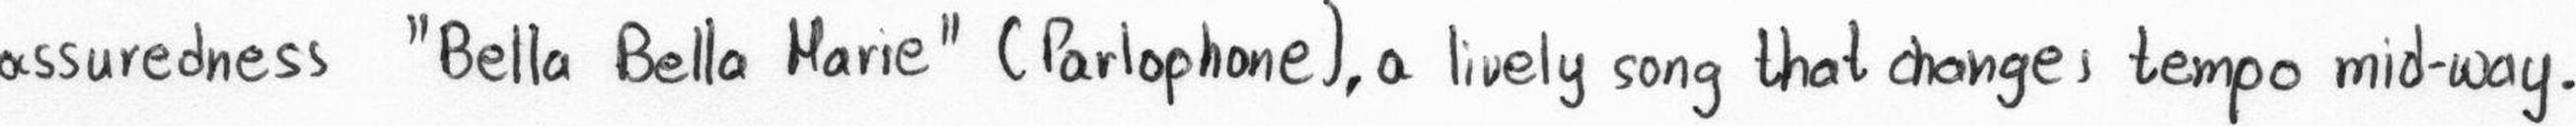

In [5]:
sample = baseline_dataset[0]

sample["image"].save("temp.jpg")
sample["image"]

In [6]:
ground_truth = sample["text"]

print("GT:", ground_truth)


GT: assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .


# Normalisasi Teks

In [7]:
# ======= STEP 4: Normalisasi Teks =======
import re

def normalize_text(text):
    text = text.strip()
    text = text.replace("\n", " ")         # newline → space
    text = re.sub(r" +", " ", text)        # multi-space → single space
    text = text.lower()                    # lowercase (case-insensitive)
    return text
# =========================================

# Evaluate Deepseek OCR before Fine Tuning

In [8]:
FastVisionModel.for_inference(model)
from jiwer import cer, wer
import os

baseline_total_cer = 0
baseline_total_wer = 0

for i, sample in enumerate(baseline_dataset):

    if os.path.exists("result.mmd"):
        os.remove("result.mmd")

    # Simpan image sementara
    sample["image"].save("temp.jpg")
    gt = normalize_text(sample["text"])

    # Jalankan OCR
    model.infer(
        tokenizer,
        prompt = "<image>\nRead the handwritten text. Output plain text only.",
        image_file="temp.jpg",
        output_path=".",
        base_size=1024,
        image_size=768,
        crop_mode=False,
        save_results=True,
        test_compress=False
    )

    # Ambil hasil OCR dari file
    with open("result.mmd", "r") as f:
        pred = normalize_text(f.read())

    # Hitung metric
    baseline_total_cer += cer(gt, pred)
    baseline_total_wer += wer(gt, pred)

    print(f"Done {i+1}/{len(baseline_dataset)}\n\n")

directly resize


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 1/500


directly resize


...

image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 499/500


directly resize



===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 500/500




In [9]:
import json

# Hitung rata-rata
baseline_avg_cer = baseline_total_cer / len(baseline_dataset)
baseline_avg_wer = baseline_total_wer / len(baseline_dataset)

print("\n=== BASELINE RESULT ===")
print("Baseline CER:", baseline_avg_cer)
print("Baseline WER:", baseline_avg_wer)

# ======= SAVE HASIL KE TXT =======
with open("/kaggle/working/baseline_results.txt", "w") as f:
    f.write("=== BASELINE RESULT ===\n")
    f.write(f"Baseline CER: {baseline_avg_cer}\n")
    f.write(f"Baseline WER: {baseline_avg_wer}\n")
print("Hasil disimpan ke baseline_results.txt")

# ======= SAVE HASIL KE JSON =======
baseline_results = {
    "model": "baseline (no fine-tuning)",
    "test_split": "test[:1000]",
    "num_samples": len(baseline_dataset),
    "avg_cer": baseline_avg_cer,
    "avg_wer": baseline_avg_wer,
}
with open("/kaggle/working/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=4)
print("Hasil disimpan ke baseline_results.json")


=== BASELINE RESULT ===
Baseline CER: 1.8149106057969022
Baseline WER: 1.8323266733266734
Hasil disimpan ke baseline_results.txt
Hasil disimpan ke baseline_results.json
